# **Phase 1: Data Engineering & Preprocessing **

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [ ]:

df = pd.read_csv('SeoulBikeData.csv', encoding='cp1252')

In [ ]:
df.columns = [
    "Date",
    "Bike_Count",
    "Hour",
    "Temperature",
    "Humidity",
    "Wind_Speed",
    "Visibility",
    "Dew_Point",
    "Solar_Radiation",
    "Rainfall",
    "Snowfall",
    "Seasons",
    "Holiday",
    "Functioning_Day"
]

df.head()

,Date,Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Dew_Point,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning_Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
print(df.isnull().sum())

Date               0
Bike_Count         0
Hour               0
Temperature        0
Humidity           0
Wind_Speed         0
Visibility         0
Dew_Point          0
Solar_Radiation    0
Rainfall           0
Snowfall           0
Seasons            0
Holiday            0
Functioning_Day    0
dtype: int64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

df.head()

,Date,Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Dew_Point,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning_Day,Month,Day,Weekday
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,1,Friday
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,1,Friday
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,1,Friday
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,1,Friday
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,1,Friday


In [ ]:
df = pd.get_dummies(
    df,
    columns=["Seasons","Holiday","Functioning_Day","Weekday"],
    drop_first=True
)

df.head()

,Date,Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Dew_Point,Solar_Radiation,Rainfall,...,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,False,True,True,True,False,False,False,False,False,False


# **Phase 2: Exploratory Data Analysis (EDA)  **


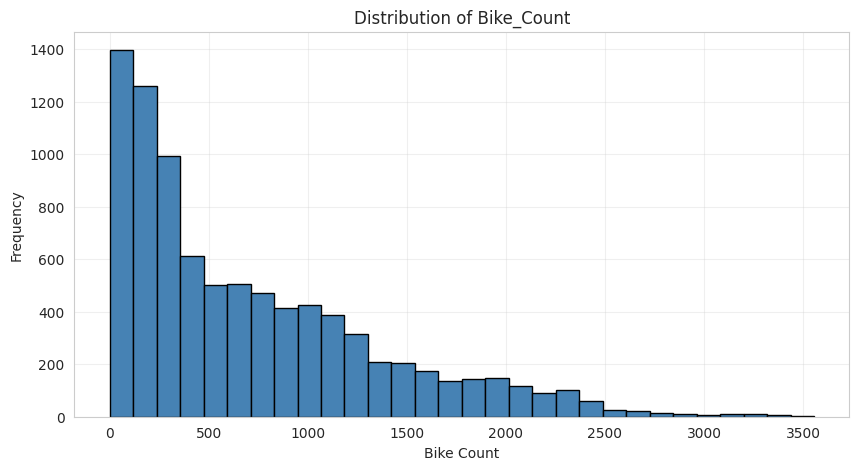

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(df['Bike_Count'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Bike_Count')
plt.xlabel('Bike Count')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

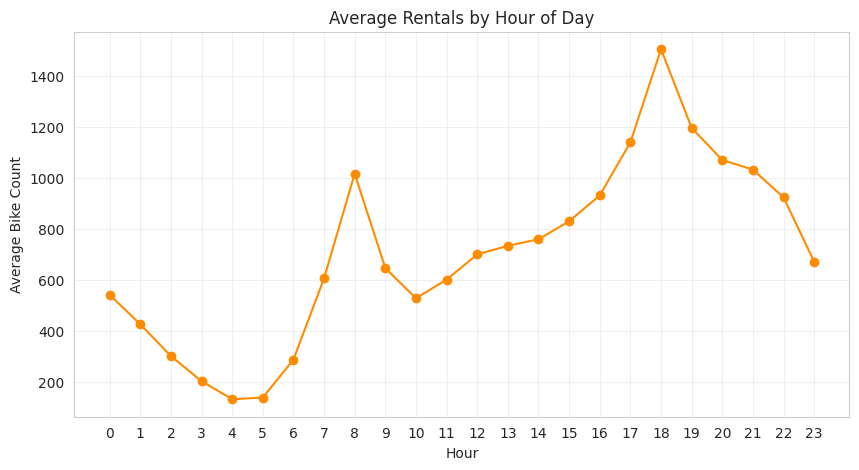

In [8]:
hourly = df.groupby('Hour')['Bike_Count'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly.index, hourly.values, marker='o', color='darkorange')
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Bike Count')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

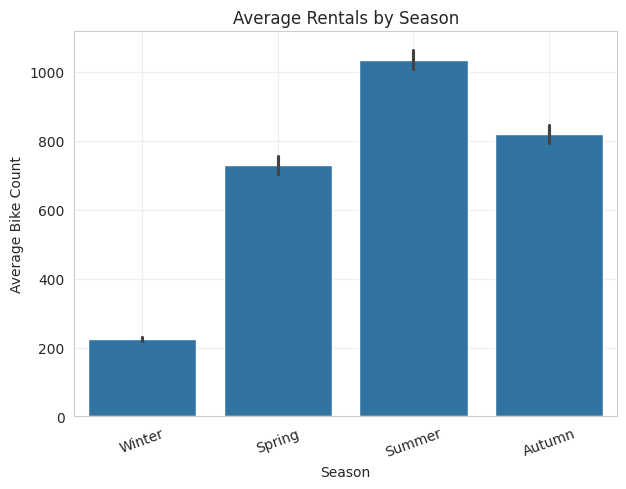

In [9]:
season_cols = [c for c in df.columns if c.startswith("Seasons_")]
season = df[season_cols].idxmax(axis=1).str.replace("Seasons_", "", regex=False)
season = season.where(df[season_cols].sum(axis=1) > 0, "Autumn")  # baseline dropped by drop_first

plt.figure(figsize=(7, 5))
sns.barplot(x=season, y=df["Bike_Count"], estimator="mean")
plt.title("Average Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Bike Count")
plt.xticks(rotation=20)
plt.grid(alpha=0.3)
plt.show()

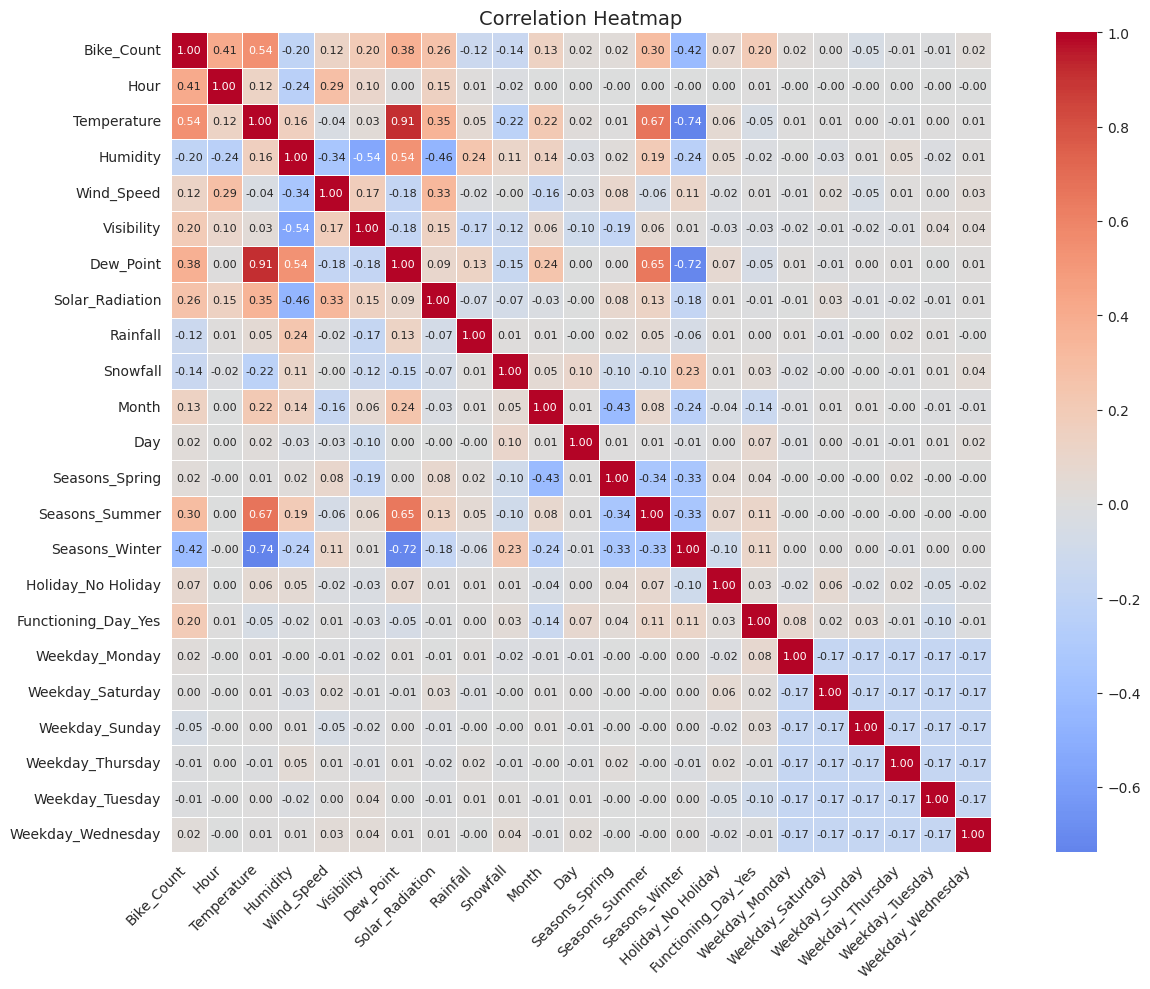

In [10]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **Phase 3: Advanced Feature Engineering**


In [11]:
df["Day_Type"] = np.where(
    (df["Holiday_No Holiday"] == 0) | (df["Date"].dt.dayofweek >= 5),
    "Leisure",
    "Work"
)

df["Day_Type"].value_counts()

Day_Type
Work       5928
Leisure    2832
Name: count, dtype: int64

In [12]:
df = pd.get_dummies(df, columns=["Day_Type"], drop_first=True)

In [13]:
df.drop("Date", axis=1, inplace=True)

if "Dew_Point" in df.columns:
    df.drop("Dew_Point", axis=1, inplace=True)

df.head()

,Bike_Count,Hour,Temperature,Humidity,Wind_Speed,Visibility,Solar_Radiation,Rainfall,Snowfall,Month,...,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Day_Type_Work
0,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,12,...,True,True,True,False,False,False,False,False,False,True
1,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,12,...,True,True,True,False,False,False,False,False,False,True
2,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,12,...,True,True,True,False,False,False,False,False,False,True
3,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,12,...,True,True,True,False,False,False,False,False,False,True
4,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,12,...,True,True,True,False,False,False,False,False,False,True


In [ ]:
df["Temp_sq"] = df["Temperature"] ** 2
df["Humidity_sq"] = df["Humidity"] ** 2

df["Temp_x_Humidity"] = df["Temperature"] * df["Humidity"]
df["Temp_x_Solar"] = df["Temperature"] * df["Solar_Radiation"]

hour_dummies = pd.get_dummies(df["Hour"], prefix="Hour", drop_first=True)
df = pd.concat([df.drop(columns=["Hour"]), hour_dummies], axis=1)

df.head()

,Bike_Count,Temperature,Humidity,Wind_Speed,Visibility,Solar_Radiation,Rainfall,Snowfall,Month,Day,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
0,254,-5.2,37,2.2,2000,0.0,0.0,0.0,12,1,...,False,False,False,False,False,False,False,False,False,False
1,204,-5.5,38,0.8,2000,0.0,0.0,0.0,12,1,...,False,False,False,False,False,False,False,False,False,False
2,173,-6.0,39,1.0,2000,0.0,0.0,0.0,12,1,...,False,False,False,False,False,False,False,False,False,False
3,107,-6.2,40,0.9,2000,0.0,0.0,0.0,12,1,...,False,False,False,False,False,False,False,False,False,False
4,78,-6.0,36,2.3,2000,0.0,0.0,0.0,12,1,...,False,False,False,False,False,False,False,False,False,False


# **Phase 4: Machine Learning (Model Training & Comparison)**


In [ ]:
X = df.drop("Bike_Count", axis=1)
y = df["Bike_Count"]

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train_log)

lr_pred = np.expm1(lr.predict(X_test))

In [ ]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
13,Functioning_Day_Yes,6.639382
42,Hour_18,0.619499
12,Holiday_No Holiday,0.578523
32,Hour_8,0.486599
4,Solar_Radiation,0.463052
43,Hour_19,0.425098
45,Hour_21,0.403203
44,Hour_20,0.400011
46,Hour_22,0.316565
41,Hour_17,0.230247


In [18]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Temperature,0.266486
13,Functioning_Day_Yes,0.084896
42,Hour_18,0.073142
22,Humidity_sq,0.065192
1,Humidity,0.058619
21,Temp_sq,0.041184
43,Hour_19,0.036223
20,Day_Type_Work,0.033185
46,Hour_22,0.029038
44,Hour_20,0.028300


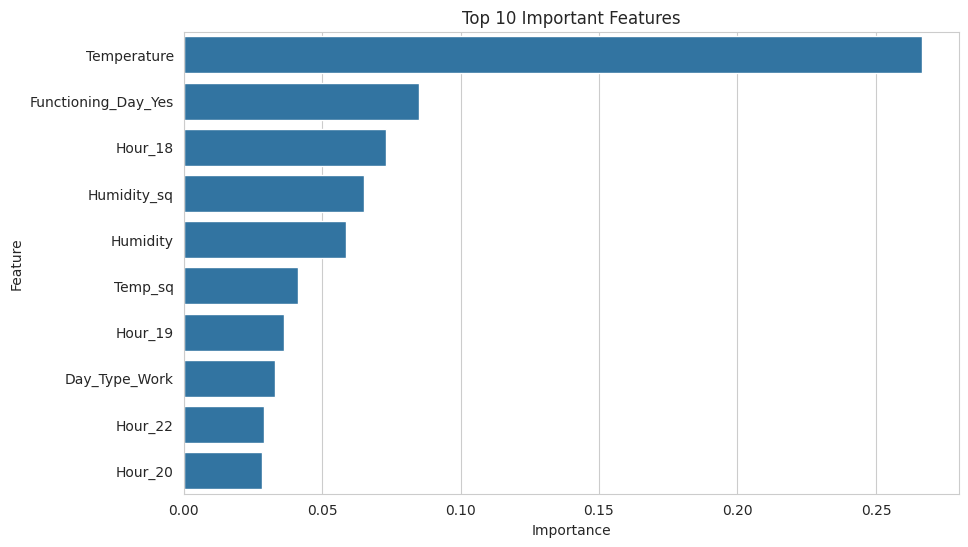

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

# **Phase 5: Evaluation **


In [ ]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("RMSE :", lr_rmse)
print("MAE  :", lr_mae)
print("R2   :", lr_r2)

In [ ]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)
print("R2   :", rf_r2)

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse
    ],

    "MAE":[
        lr_mae,
        rf_mae
    ],

    "R2 Score":[
        lr_r2,
        rf_r2
    ]

})

comparison

# **The "Real World" Test **


In [ ]:
sample = X.iloc[[0]].copy()

for col in [c for c in X.columns if c.startswith("Hour_")]:
    sample[col] = 0

sample["Hour_8"] = 1 if "Hour_8" in X.columns else 0
sample["Temperature"] = 25
sample["Temp_sq"] = 25 ** 2
sample["Rainfall"] = 0
sample["Humidity_sq"] = sample["Humidity"].values[0] ** 2
sample["Temp_x_Humidity"] = 25 * sample["Humidity"].values[0]
sample["Temp_x_Solar"] = 25 * sample["Solar_Radiation"].values[0]

prediction_lr = np.expm1(lr.predict(sample))
prediction_rf = rf.predict(sample)

print("Linear Regression Prediction:", prediction_lr[0])
print("Random Forest Prediction:", prediction_rf[0])

Linear Regression Prediction: 1474.678190479901
Random Forest Prediction: 1040.9267401529692
